In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Affine arithmetic library
import affapy as af
from affapy.aa import Affine
from affapy.ia import Interval

CASE 1: All independent uncertainties

In [9]:
def beam_deflection(x, P, E, L, b, h):

    I = (b * h*h*h)/12
    deflection = P * x*x * ((3*L - x)/(6*E*I))

    return deflection

In [15]:
# Set a percentage to define each interval
percentage = 0.10

P_midpoint = 500 # [N]
P_lower, P_upper = P_midpoint*(1-percentage), P_midpoint*(1+percentage)
P_radius = (P_upper-P_lower)/2
P = Interval(P_lower, P_upper)

E_midpoint = 210e9 # [Pa]
E_lower, E_upper = E_midpoint*(1-percentage), E_midpoint*(1+percentage)
E_radius = (E_upper-E_lower)/2
E = Interval(E_lower, E_upper)

L_midpoint = 2 # [m]
L_lower, L_upper = L_midpoint*(1-percentage), L_midpoint*(1+percentage)
L_radius = (L_upper-L_lower)/2
L = Interval(L_lower, L_upper)

b_midpoint = 0.1 # [m]
b_lower, b_upper = b_midpoint*(1-percentage), b_midpoint*(1+percentage)
b_radius = (b_upper-b_lower)/2
B = Interval(b_lower, b_upper)

h_midpoint = 0.04 # [m]
h_lower, h_upper = h_midpoint*(1-percentage), h_midpoint*(1+percentage)
h_radius = (h_upper-h_lower)/2
H = Interval(h_lower, h_upper)

# Let x be deterministic for now at the free end tip
x = L_midpoint

# Compute deflection using traditional interval arithemetic
IA_deflection = beam_deflection(x, P, E, L, B, H)
print(IA_deflection.width())


0.0198486166145974


In [11]:
# Convert to affine arithmetic, we will use lower case symbols instead
p = Affine(x0=P_midpoint, xi={1:(P_radius)})
e = Affine(x0=E_midpoint, xi={2:(E_radius)})
l = Affine(x0=L_midpoint, xi={3:(L_radius)})
b = Affine(x0=b_midpoint, xi={4:(b_radius)})
h = Affine(x0=h_midpoint, xi={5:(h_radius)})

print(p)
print(e)
print(l)
print(b)
print(h)
AA_deflection = beam_deflection(x, p, e, l, b, h) 
print(AA_deflection)
print(AA_deflection.interval)


500.0 + 50.0e1
210000000000.0 + 21000000000.0e2
2.0 + 0.2e3
0.1 + 0.01e4
0.04 + 0.004e5
0.018978460326604 + 0.0018978460326604e1 + -0.000458980106463729e2 + 0.0028467690489906e3 + -0.000458980106463728e4 + -0.00137694031939119e5 + -4.58980106463728e-5e20 + -9.6385822357383e-5e21 + -0.000151922415239494e22 + -0.000213012667409817e23 + 0.00878442036602331e24 + 0.00173798097209925e25 + 0.00161712898350849e26
[-0.000707804524649757, 0.0386647251778578]


In [12]:
# Lets assign the same uncertainty source (i.e. e1 for all variables)
p = Affine(x0=P_midpoint, xi={1:(P_radius)})
e = Affine(x0=E_midpoint, xi={1:(E_radius)})
l = Affine(x0=L_midpoint, xi={1:(L_radius)})
b = Affine(x0=b_midpoint, xi={1:(b_radius)})
h = Affine(x0=h_midpoint, xi={1:(h_radius)})

print(p)
print(e)
print(l)
print(b)
print(h)

AA_deflection_shared = beam_deflection(x, p, e, l, b, h) 
print(AA_deflection_shared)
print(AA_deflection_shared.interval)


500.0 + 50.0e1
210000000000.0 + 21000000000.0e1
2.0 + 0.2e1
0.1 + 0.01e1
0.04 + 0.004e1
0.018978460326604 + 0.00244971454933236e1 + -4.58980106463728e-5e27 + -9.6385822357383e-5e28 + -0.000151922415239494e29 + -0.000213012667409816e30 + 0.00878442036602331e31 + 0.00173798097209925e32 + 0.00115814887704476e33
[0.00434097664645125, 0.0336159440067568]


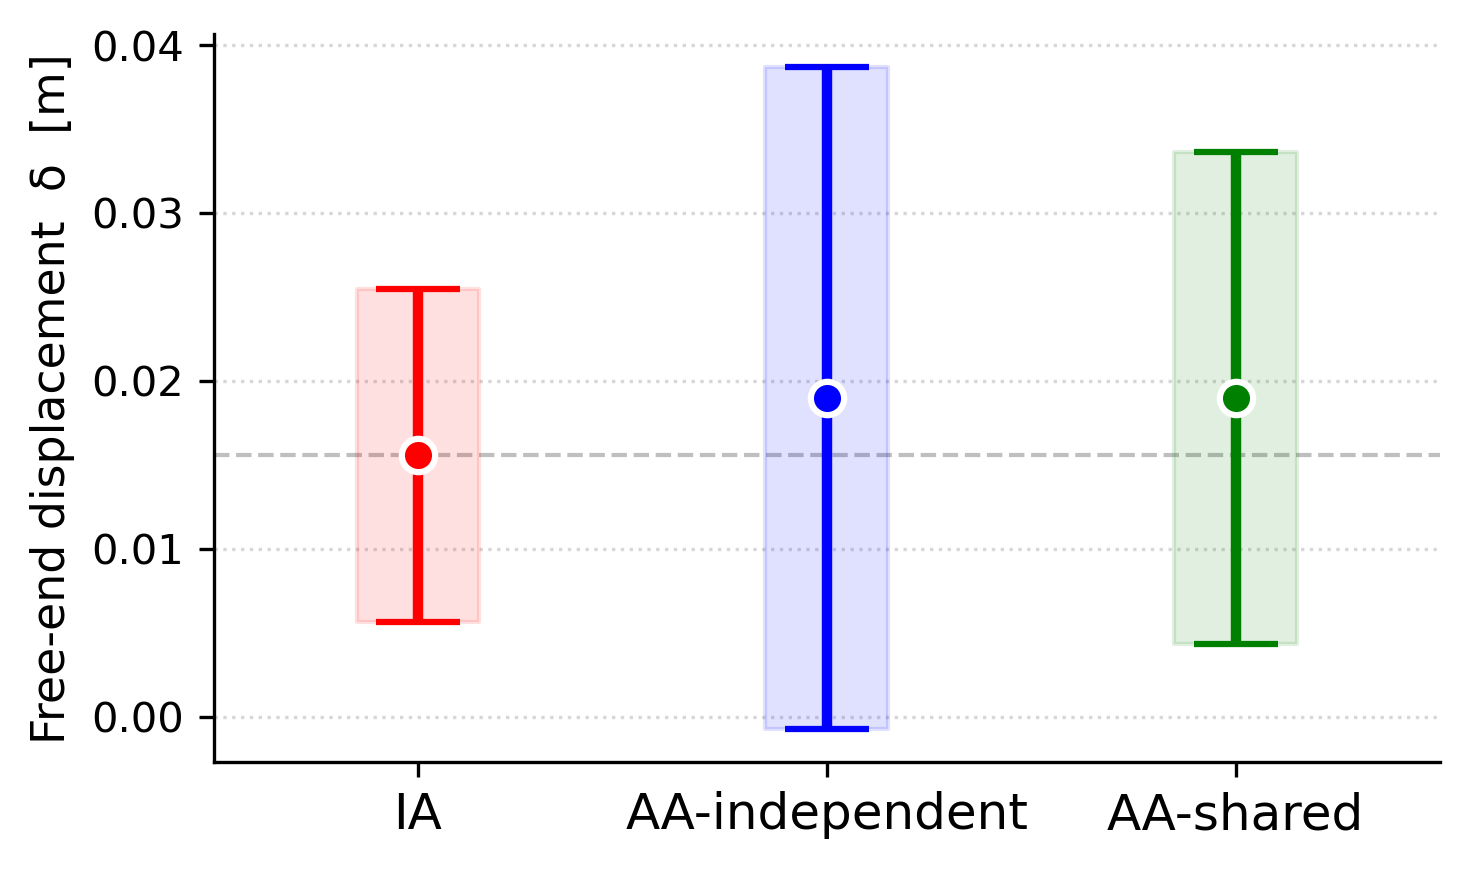

In [16]:
labels  = ["IA", "AA-independent", "AA-shared"]
centers = [float(IA_deflection.mid()),       float(AA_deflection.x0),  float(AA_deflection_shared.x0)]
errors  = [float(IA_deflection.radius()),       float(AA_deflection.rad()),  float(AA_deflection_shared.rad())]

x = np.arange(len(labels))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

colors      = ["red", "blue", "green"]
cap_size    = 10
marker_size = 8

for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.errorbar(
        xi, ci, yerr=ei,
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.5,
        capsize=cap_size,
        capthick=2.5,
        markersize=marker_size,
        markeredgewidth=1.5,
        markeredgecolor="white",
        label=f"{labels[i]}:  [{ci-ei:.4f}, {ci+ei:.4f}]  (width = {2*ei:.4f})",
        zorder=3,
    )

# Horizontal reference line at the nominal (central) value
ax.axhline(centers[0], color="gray", linestyle="--", linewidth=1,
           alpha=0.5, label="Nominal value")

# Shaded interval bands for visual comparison
for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.fill_between([xi - 0.15, xi + 0.15], ci - ei, ci + ei,
                    color=color, alpha=0.12, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Free-end displacement  δ  [m]", fontsize=11)

# ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
"""
Cantilever Tip Deflection: Interval vs Affine Arithmetic
=========================================================
Formula (at x = L):  d = P·L³ / (3·E·I)

Compares the enclosure width produced by:
  - Interval Arithmetic (IA)  — affapy.ia
  - Affine Arithmetic   (AA)  — affapy.aa
"""

import affapy.aa as aa
import affapy.ia as ia

# ── Parameters ────────────────────────────────────────────────────
P_m, L_m, E_m, I_m = 1000.0, 1.0, 200e9, 9e-8   # midpoint values
UNCERTAINTY = 0.05                                  # ±5%

P_lo, P_hi = P_m * (1 - UNCERTAINTY), P_m * (1 + UNCERTAINTY)
L_lo, L_hi = L_m * (1 - UNCERTAINTY), L_m * (1 + UNCERTAINTY)
E_lo, E_hi = E_m * (1 - UNCERTAINTY), E_m * (1 + UNCERTAINTY)
I_lo, I_hi = I_m * (1 - UNCERTAINTY), I_m * (1 + UNCERTAINTY)

d_exact = P_m * L_m**3 / (3 * E_m * I_m)

# ── Interval Arithmetic ────────────────────────────────────────────
P_i = ia.Interval(P_lo, P_hi)
L_i = ia.Interval(L_lo, L_hi)
E_i = ia.Interval(E_lo, E_hi)
I_i = ia.Interval(I_lo, I_hi)

d_ia  = (P_i * L_i**3) / (ia.Interval(3, 3) * E_i * I_i)
ia_lo = float(d_ia.inf)
ia_hi = float(d_ia.sup)
ia_w  = float(d_ia.width())

# ── Affine Arithmetic ──────────────────────────────────────────────
# Use explicit L_a * L_a * L_a so the shared noise symbol for L is
# preserved across all three occurrences — this is what allows AA
# to track the internal correlation of L with itself.
P_a = aa.Affine([P_lo, P_hi])
L_a = aa.Affine([L_lo, L_hi])
E_a = aa.Affine([E_lo, E_hi])
I_a = aa.Affine([I_lo, I_hi])

d_aa  = (P_a * L_a * L_a * L_a) / (aa.Affine([3, 3]) * E_a * I_a)
aa_lo = float(d_aa.interval.inf)
aa_hi = float(d_aa.interval.sup)
aa_w  = float(d_aa.interval.width())

# ── Report ─────────────────────────────────────────────────────────
print("=" * 65)
print("  Cantilever Tip Deflection: IA vs AA Comparison")
print("  d = P·L³ / (3·E·I)   at x = L")
print("=" * 65)

print(f"\nParameters (midpoint ±{UNCERTAINTY*100:.0f}%):")
print(f"  P = [{P_lo:.4g}, {P_hi:.4g}] N")
print(f"  L = [{L_lo:.4g}, {L_hi:.4g}] m")
print(f"  E = [{E_lo:.3e}, {E_hi:.3e}] Pa")
print(f"  I = [{I_lo:.3e}, {I_hi:.3e}] m⁴")
print(f"\n  Exact midpoint d = {d_exact:.6e} m")

print(f"\n{'Method':<8} {'Lower bound':>14} {'Upper bound':>14} {'Width':>14} {'Midpoint':>14}")
print("-" * 66)
print(f"{'IA':<8} {ia_lo:>14.6e} {ia_hi:>14.6e} {ia_w:>14.6e} {(ia_lo+ia_hi)/2:>14.6e}")
print(f"{'AA':<8} {aa_lo:>14.6e} {aa_hi:>14.6e} {aa_w:>14.6e} {(aa_lo+aa_hi)/2:>14.6e}")

tighter = "IA" if ia_w < aa_w else "AA"
pct_diff = abs(ia_w - aa_w) / min(ia_w, aa_w) * 100
print(f"\n  → {tighter} produces a tighter enclosure")
print(f"    IA width / AA width = {ia_w/aa_w:.4f}")
print(f"    IA is {pct_diff:.1f}% {'narrower' if ia_w < aa_w else 'wider'} than AA")

print("""
Note: IA is tighter here because all four parameters (P, L, E, I)
are INDEPENDENT variables. AA's advantage over IA — dependency
tracking via shared noise symbols — only helps when the SAME
variable appears multiple times in independent branches of the
expression. In d = P·L³/(3·E·I), AA does track L across the
three multiplications, but its linearisation of each nonlinear
product introduces rounding error terms that more than offset
this gain.  AA would strictly outperform IA for expressions
such as (L - L) or (f(L) / g(L)) where IA inflates the result
due to treating each L occurrence as a fresh independent interval.
""")

# ── Width sweep ────────────────────────────────────────────────────
print("Width vs uncertainty level:")
print(f"\n  {'Uncert':>8} {'IA width':>14} {'AA width':>14} {'Ratio IA/AA':>13} {'Tighter':>8}")
print("  " + "-" * 60)

for pct in [1, 2, 3, 5, 7, 10, 15, 20]:
    g = pct / 100.0

    L2_i = ia.Interval(L_m*(1-g), L_m*(1+g))
    P2_i = ia.Interval(P_m*(1-g), P_m*(1+g))
    E2_i = ia.Interval(E_m*(1-g), E_m*(1+g))
    I2_i = ia.Interval(I_m*(1-g), I_m*(1+g))
    w_ia = float(((P2_i * L2_i**3) / (ia.Interval(3,3) * E2_i * I2_i)).width())

    L2_a = aa.Affine([L_m*(1-g), L_m*(1+g)])
    P2_a = aa.Affine([P_m*(1-g), P_m*(1+g)])
    E2_a = aa.Affine([E_m*(1-g), E_m*(1+g)])
    I2_a = aa.Affine([I_m*(1-g), I_m*(1+g)])
    w_aa = float(((P2_a * L2_a * L2_a * L2_a) / (aa.Affine([3,3]) * E2_a * I2_a)).interval.width())

    r = w_ia / w_aa
    tighter = "IA" if r < 1 else "AA"
    print(f"  {pct:>6}%   {w_ia:>14.6e} {w_aa:>14.6e} {r:>13.4f} {tighter:>8}")

  Cantilever Tip Deflection: IA vs AA Comparison
  d = P·L³ / (3·E·I)   at x = L

Parameters (midpoint ±5%):
  P = [950, 1050] N
  L = [0.95, 1.05] m
  E = [1.900e+11, 2.100e+11] Pa
  I = [8.550e-08, 9.450e-08] m⁴

  Exact midpoint d = 1.851852e-02 m

Method      Lower bound    Upper bound          Width       Midpoint
------------------------------------------------------------------
IA         1.368113e-02   2.494114e-02   1.126000e-02   1.931113e-02
AA         1.235021e-02   2.508008e-02   1.272988e-02   1.871514e-02

  → IA produces a tighter enclosure
    IA width / AA width = 0.8845
    IA is 13.1% narrower than AA

Note: IA is tighter here because all four parameters (P, L, E, I)
are INDEPENDENT variables. AA's advantage over IA — dependency
tracking via shared noise symbols — only helps when the SAME
variable appears multiple times in independent branches of the
expression. In d = P·L³/(3·E·I), AA does track L across the
three multiplications, but its linearisation of each nonl